# 02 — Exploring the data (how every cleaning decision was found)
Run from the `notebooks/` directory. This is the working notebook behind `src/cleaning.py` and `src/features.py`: each section starts with a question, looks at the data (plots + tables), and ends with the decision it caused.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
tr = pd.read_csv('../data/train_test.csv', parse_dates=['date'])
va = pd.read_csv('../data/validation.csv', parse_dates=['date'])
print('train', tr.shape, '|', tr['date'].min().date(), '->', tr['date'].max().date())
print('val  ', va.shape, '|', va['date'].min().date(), '->', va['date'].max().date())
print('\nmissing per column (train):')
print(tr.isna().sum()[tr.isna().sum() > 0].to_string())

train (48000, 14) | 2025-01-01 -> 2025-10-31
val   (12000, 13) | 2025-11-01 -> 2025-12-31

missing per column (train):
weight          300
market_index    374


## Q1: weight looks odd — negatives? a ceiling?
Trucks can't carry negative pounds, and the max (47,500) is suspiciously round. Let's look.

negatives: 292 | NaN: 300 | min/max: -47500.0 47500.0

most common exact values:
weight
 47500.0    1191
 5000.0       31
-47500.0      13
 32436.0      10
 32153.0      10
 28444.0       9


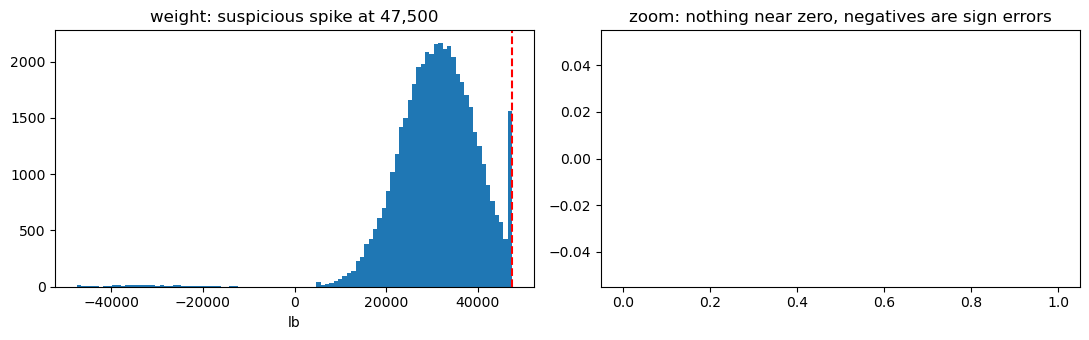

In [2]:
w = tr['weight']
print('negatives:', (w < 0).sum(), '| NaN:', w.isna().sum(), '| min/max:', w.min(), w.max())
print('\nmost common exact values:')
print(w.value_counts().head(6).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(w.dropna(), bins=100); ax[0].axvline(47500, color='r', ls='--')
ax[0].set_title('weight: suspicious spike at 47,500'); ax[0].set_xlabel('lb')
ax[1].hist(w[(w > 0) & (w < 2000)].dropna(), bins=50)
ax[1].set_title('zoom: nothing near zero, negatives are sign errors')
plt.tight_layout(); plt.show()

**Observation:** one exact value (47,500) occurs ~1,200x while neighbours occur ~10x: a system cap, not real measurements. Negatives mirror positives: sign-entry errors.
**Decision:** `abs()` + median impute + `weight_missing / weight_was_negative / weight_capped` flags (`cleaning.py`).

## Q2: does distance have a floor?
Smallest value is exactly 70.0 — and it is also the single most common value. Same pile-up test.

min: 70.0 | exactly 70.0: 48
distance
70.0     48
446.3    12
741.1    11
758.9    11


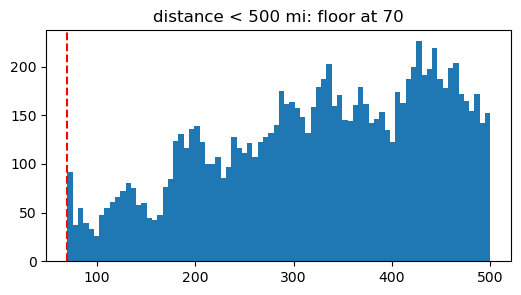

In [3]:
d = tr['distance']
print('min:', d.min(), '| exactly 70.0:', (d == 70.0).sum())
print(d.value_counts().head(4).to_string())
plt.figure(figsize=(6, 3)); plt.hist(d[d < 500], bins=80); plt.axvline(70, color='r', ls='--')
plt.title('distance < 500 mi: floor at 70'); plt.show()

**Decision:** `dist_floor` flag (`cleaning.py`). Kept the rows — a 70-mile load is still a load.

## Q3: is the target well-behaved? (spoiler: no)
Right-skewed rates plus a few absurd values. Max (~25k) vs 99th percentile (~6k) already smells like corruption — confirmed in notebook 03.

count    48000.0
mean      2374.0
std       1486.5
min         57.2
50%       2030.8
95%       4953.8
99%       5972.8
max      25533.0


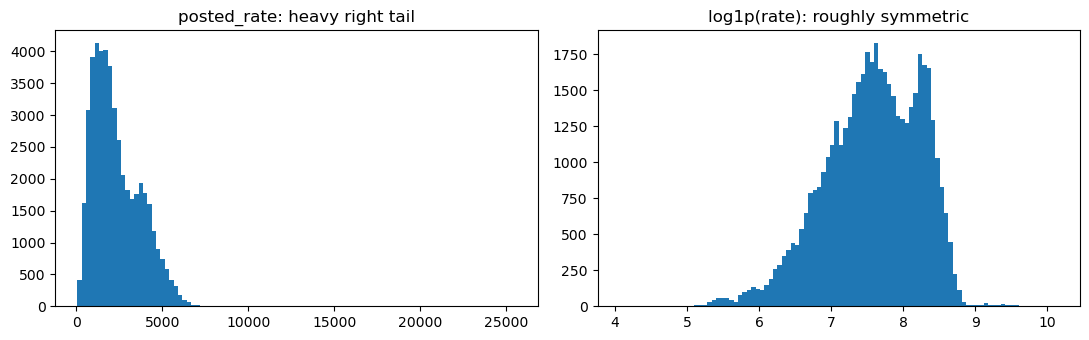

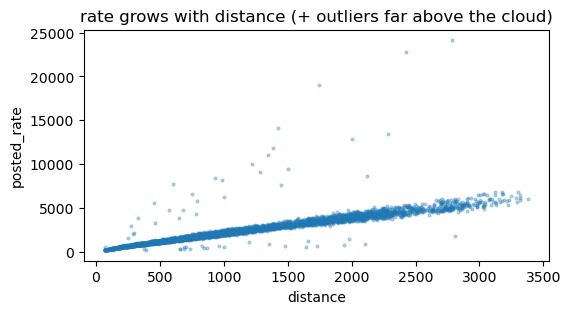

In [4]:
y = tr['posted_rate']
print(y.describe([.5, .95, .99]).round(1).to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(y, bins=100); ax[0].set_title('posted_rate: heavy right tail')
ax[1].hist(np.log1p(y), bins=100); ax[1].set_title('log1p(rate): roughly symmetric')
plt.tight_layout(); plt.show()
s = tr.sample(4000, random_state=0)
plt.figure(figsize=(6, 3)); plt.scatter(s['distance'], s['posted_rate'], s=4, alpha=0.3)
plt.xlabel('distance'); plt.ylabel('posted_rate')
plt.title('rate grows with distance (+ outliers far above the cloud)'); plt.show()

**Decision:** model `log1p(rate)` with an L1 loss; never delete rows (`model.py`). Full proof in notebook 03.

## Q4: market_index — signal or trap?
It has a huge weekly swing. But do prices actually follow it?

market NaN train/val: 374 249
market mean train/val: 1.083 / 0.927  <-- regime drift!


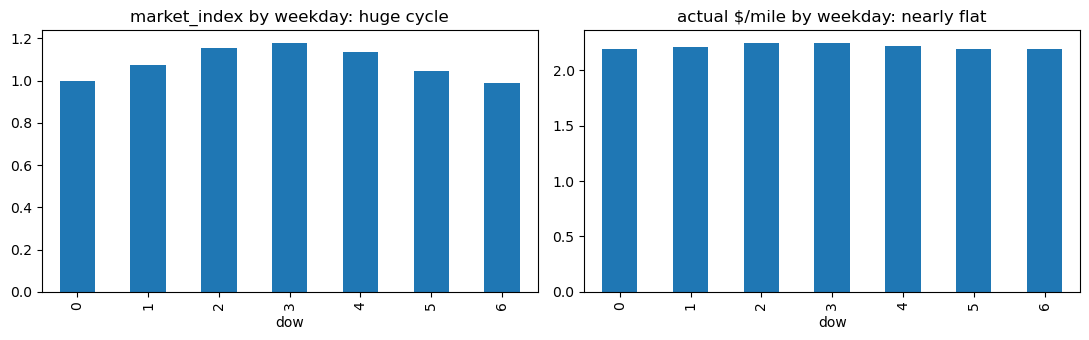

In [5]:
print('market NaN train/val:', tr['market_index'].isna().sum(), va['market_index'].isna().sum())
print('market mean train/val: %.3f / %.3f  <-- regime drift!' % (tr['market_index'].mean(), va['market_index'].mean()))
tr['dow'] = tr['date'].dt.dayofweek; tr['rpm'] = tr['posted_rate'] / tr['distance']
g = tr.groupby('dow').agg(mi=('market_index', 'mean'), rpm=('rpm', 'mean'))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)
g['mi'].plot.bar(ax=ax[0], title='market_index by weekday: huge cycle')
g['rpm'].plot.bar(ax=ax[1], title='actual $/mile by weekday: nearly flat')
plt.tight_layout(); plt.show()

**Observation:** market swings ~20% across the week, prices move ~2%. Raw index would mislead the trees.
**Decision:** daily-median smoothing (`mi_smooth`) + keep raw + missing flag (`features.py`).

## Q5: what does quote_signal actually do?
Correlation with rate is near zero — yet binned against $/mile it draws a clear U. Trees love this shape; linear models cannot see it.

corr quote-rate: -0.040 (looks useless!)


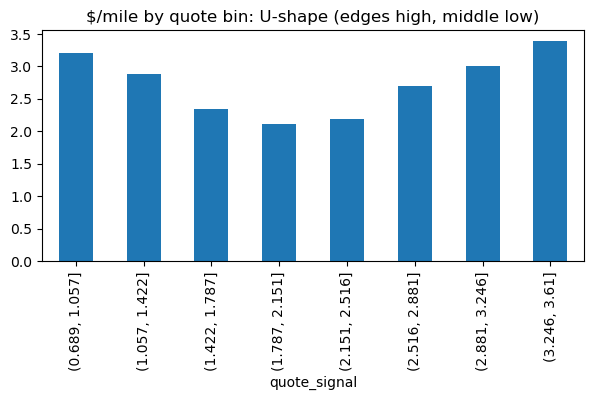

In [6]:
print('corr quote-rate: %.3f (looks useless!)' % tr['quote_signal'].corr(tr['posted_rate']))
qb = tr.groupby(pd.cut(tr['quote_signal'], 8), observed=True)['rpm'].mean()
qb.plot.bar(figsize=(7, 3), title='$/mile by quote bin: U-shape (edges high, middle low)'); plt.show()

**Decision:** add `qs_dev = |quote - median|` so a single split captures both expensive edges (`features.py`).

## Q6: will city names survive validation? (no)
Eight validation cities never appear in training. Any city-ID feature breaks on them — coordinates do not.

In [7]:
tr_c = set(tr['pickup']) | set(tr['delivery']); va_c = set(va['pickup']) | set(va['delivery'])
new = sorted(va_c - tr_c)
print(len(new), 'unseen cities:', new)
print('rows touching a new city: %.1f%%' % ((va['pickup'].isin(new) | va['delivery'].isin(new)).mean() * 100))

8 unseen cities: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
rows touching a new city: 12.1%


**Decision:** coordinates only, no city IDs (`features.py`). Both December cities exist in train, so the chart is safe.